### Perceptrons, Logical Functions, and the XOR problem
- Link to: https://medium.com/data-science/perceptrons-logical-functions-and-the-xor-problem-37ca5025790a

In Part 1 of this series, we introduced the Perceptron as a model that implements the following function:
$\hat{y}=\Theta(w_1x_1+w_2x_2+...+w_nx_n+b) = \Theta(W \cdot X +b )$ 
where

$$
\Theta(v) = 
\begin{cases}
    1 & \text{if } v \geq 0 \\
    0 & \text{otherwise }
\end{cases}
$$


### Computational Graph
To visualize the architecture of a model, we use what is called computational graph: a directed graph which is used to represent a math function. Both variables and operations are nodes; variables are fed into operations and operations produce variables.

The computational graph of our perceptron is:

![Screenshot 2025-05-11 at 3.23.53 in the afternoon.png](<attachment:Screenshot 2025-05-11 at 3.23.53 in the afternoon.png>)
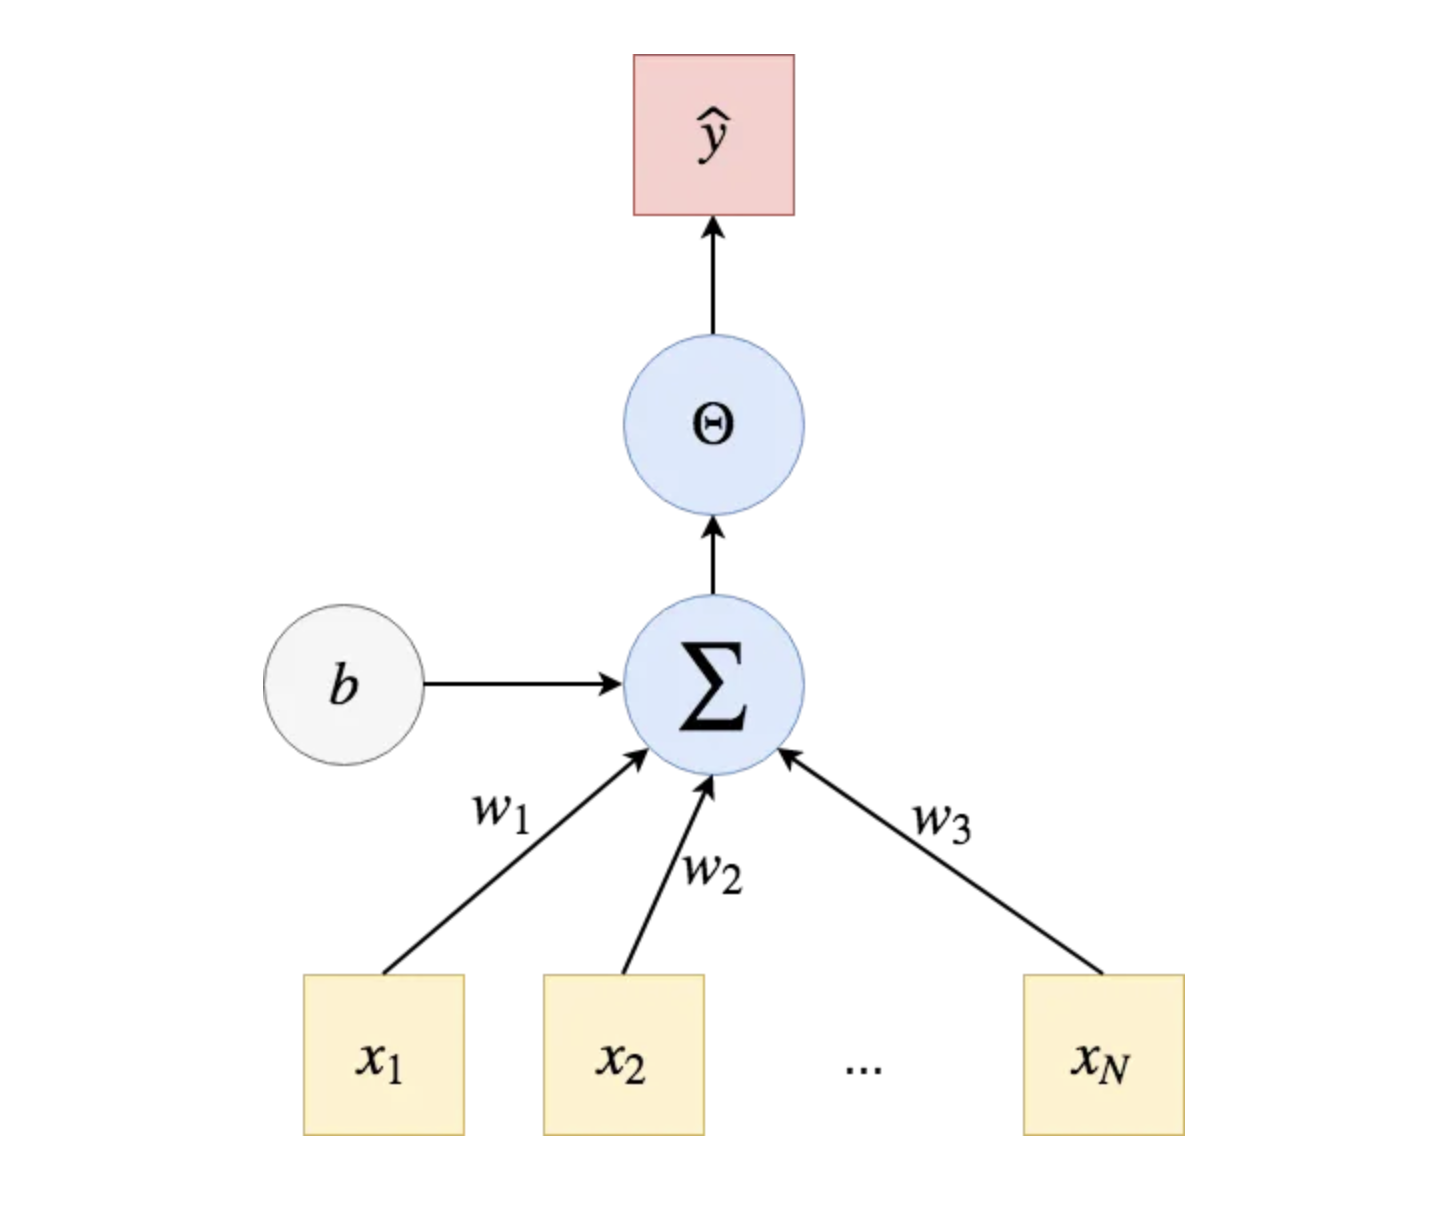

The Σ symbol represents the linear combination of the inputs x by means of the weights w and the bias b. Since this notation is quite heavy, from now on I will simplify the computational graph in the following way:

![Screenshot 2025-05-11 at 3.51.30 in the afternoon.png](<attachment:Screenshot 2025-05-11 at 3.51.30 in the afternoon.png>)
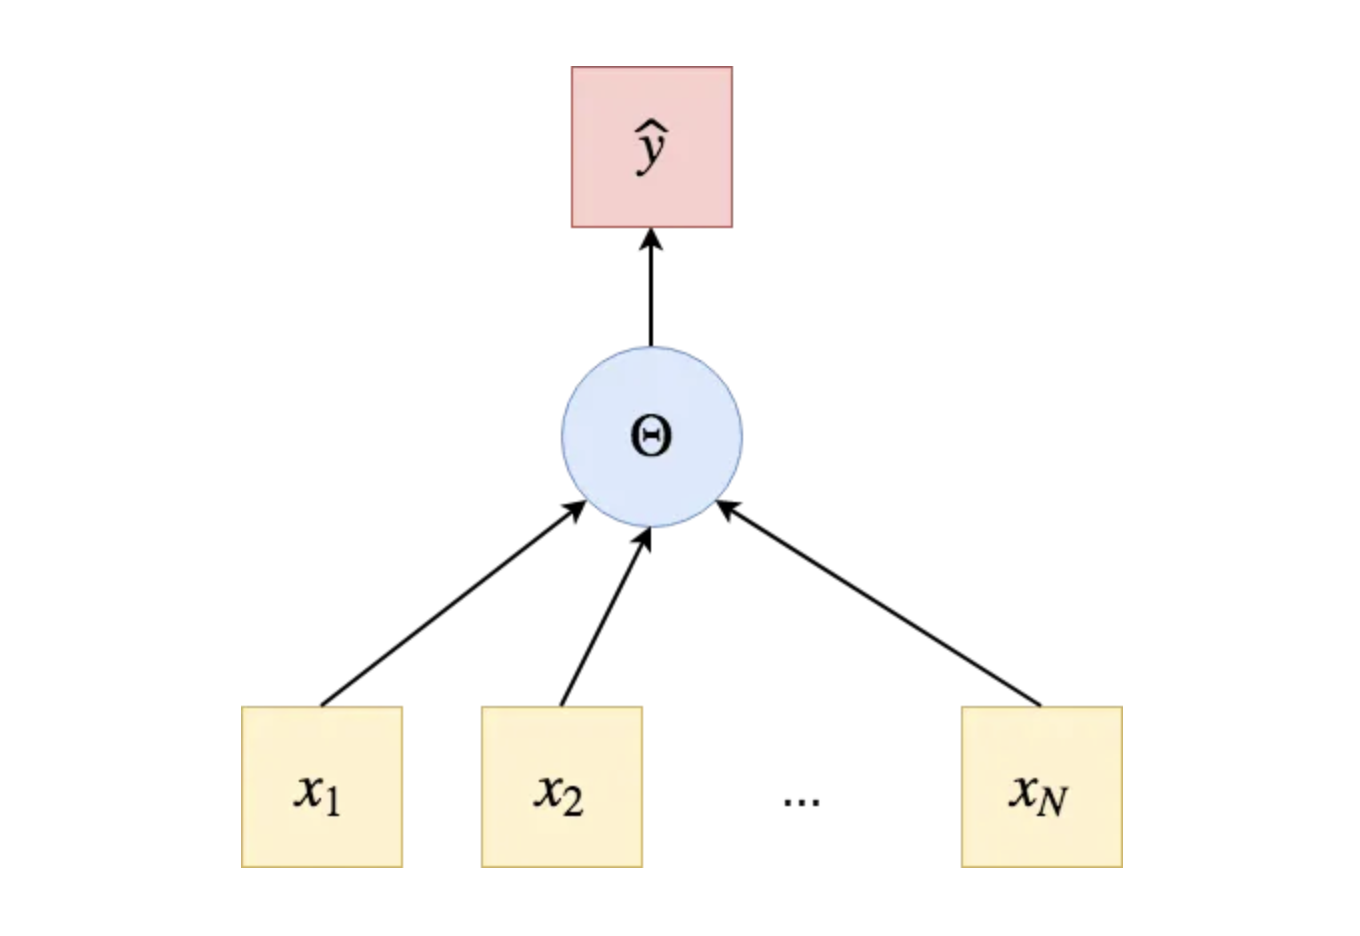

### What can a perceptron do?
I am introducing some examples of what a perceptron can implement with its capacity (I will talk about this term in the following parts of this series!). Logical functions are a great starting point since they will bring us to a natural development of the theory behind the perceptron and, as a consequence, neural networks.

### NOT logical function
Let’s start with a very simple problem:

Can a perceptron implement the NOT logical function?

In [2]:
import numpy as np

def unit_step(v):
	""" Heavyside Step function. v must be a scalar """
	if v >= 0:
		return 1
	else:
		return 0
	
def perceptron(x, w, b):
	# Function implemented by a perceptron with weight vector w and bias b
    # v = np.dot(w, x) + b
    # y = unit_step(v)
	v = np.dot(w, x) + b
	y = unit_step(v)
	return y

def NOT_percep(x):
	return perceptron(x, w=-1, b=0.5)

print("NOT(0) = {}".format(NOT_percep(0)))
print("NOT(1) = {}".format(NOT_percep(1)))

NOT(0) = 1
NOT(1) = 0


We conclude that the answer to the initial question is: yes, a perceptron can implement the NOT logical function; we just need to properly set its parameters. Notice that my solution isn’t unique; in fact, solutions, intended as (w, b) points, are infinite for this particular problem! You can use your favorite one ;)

### AND logical function
Can a perceptron implement the AND logical function?
![Screenshot 2025-05-11 at 10.22.29 at night.png](<attachment:Screenshot 2025-05-11 at 10.22.29 at night.png>)

$\hat{y}=\Theta(w_1x_1+w_2x_2+b)$
This time, we have three parameters: w1, w2, and b. Can you guess which are three values for these parameters which would allow the perceptron to solve the AND problem?
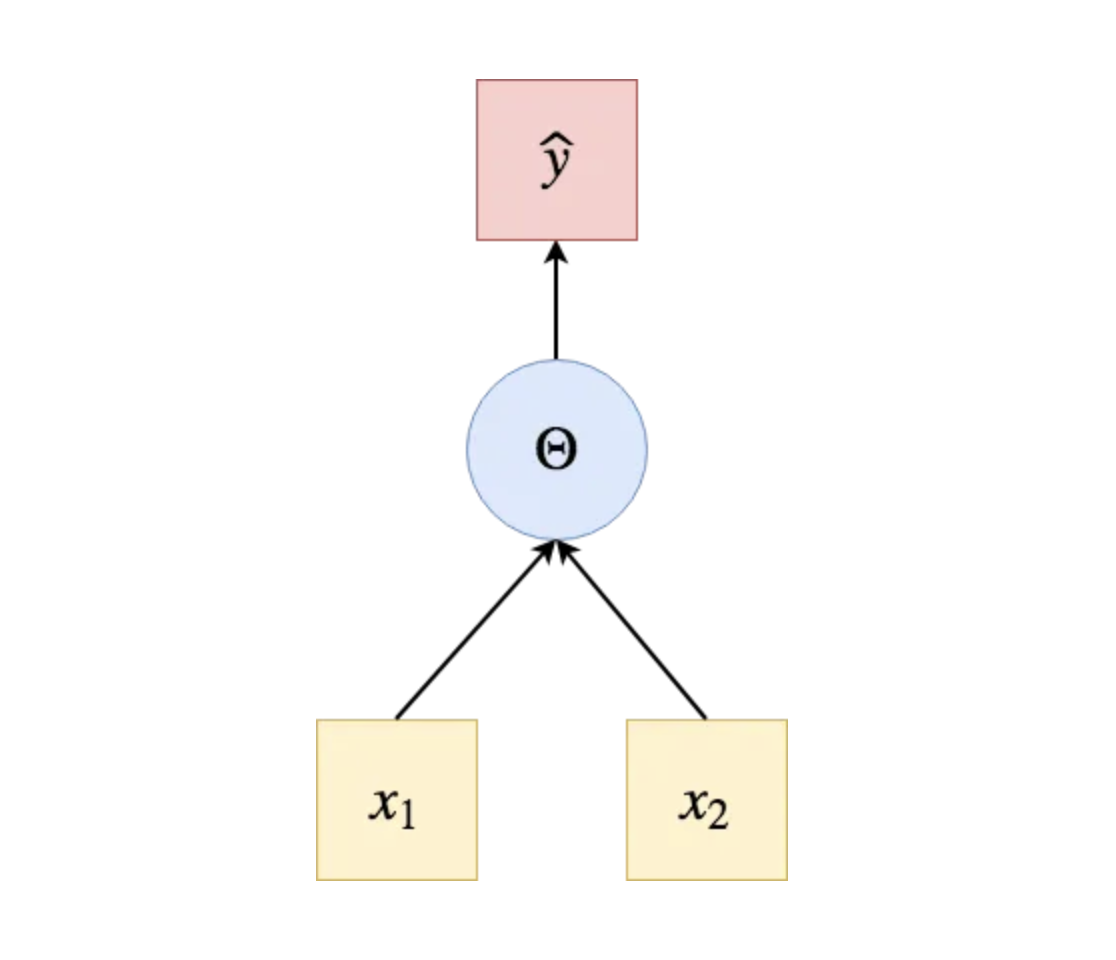

In [3]:
# SOLUTION:
# w1 = 1, w2 = 1, b = -1.5

def AND_percep(x):
    w = np.array([1, 1])
    b = -1.5
    return perceptron(x, w, b)

# Test
example1 = np.array([1, 1])
example2 = np.array([1, 0])
example3 = np.array([0, 1])
example4 = np.array([0, 0])

print("AND({}, {}) = {}".format(1, 1, AND_percep(example1)))
print("AND({}, {}) = {}".format(1, 0, AND_percep(example2)))
print("AND({}, {}) = {}".format(0, 1, AND_percep(example3)))
print("AND({}, {}) = {}".format(0, 0, AND_percep(example4)))

AND(1, 1) = 1
AND(1, 0) = 0
AND(0, 1) = 0
AND(0, 0) = 0


### OR logical function
OR(x1, x2) is a 2-variables function too, and its output is 1-dimensional (i.e., one number) and has two possible states (0 or 1). Therefore, we will use a perceptron with the same architecture as the one before. Which are the three parameters which solve the OR problem?

In [4]:
"""
    SOLUTION:
    w1 = 1, w2 = 1, b = -0.5
    This was provided the answer that you see in the above cell. 
    For OR logic, we need to find W1, W2 and b such that we can get the results based the truth tables. where b is the threshold.
    The OR function is true if at least one of the inputs is true.
"""

def OR_percep(x):
    w = np.array([1, 1])
    b = -0.5
    return perceptron(x, w, b)

# Test
example1 = np.array([1, 1])
example2 = np.array([1, 0])
example3 = np.array([0, 1])
example4 = np.array([0, 0])

print("OR({}, {}) = {}".format(1, 1, OR_percep(example1)))
print("OR({}, {}) = {}".format(1, 0, OR_percep(example2)))
print("OR({}, {}) = {}".format(0, 1, OR_percep(example3)))
print("OR({}, {}) = {}".format(0, 0, OR_percep(example4)))

OR(1, 1) = 1
OR(1, 0) = 1
OR(0, 1) = 1
OR(0, 0) = 0


### XOR — ALL (perceptrons) FOR ONE (logical function)
We conclude that a single perceptron with an Heaviside activation function can implement each one of the fundamental logical functions: NOT, AND and OR.
They are called fundamental because any logical function, no matter how complex, can be obtained by a combination of those three. We can infer that, if we appropriately connect the three perceptrons we just built, we can implement any logical function! Let’s see how:

How can we build a network of fundamental logical perceptrons so that it implements the XOR function?

![Screenshot 2025-05-11 at 11.04.35 at night.png](<attachment:Screenshot 2025-05-11 at 11.04.35 at night.png>)
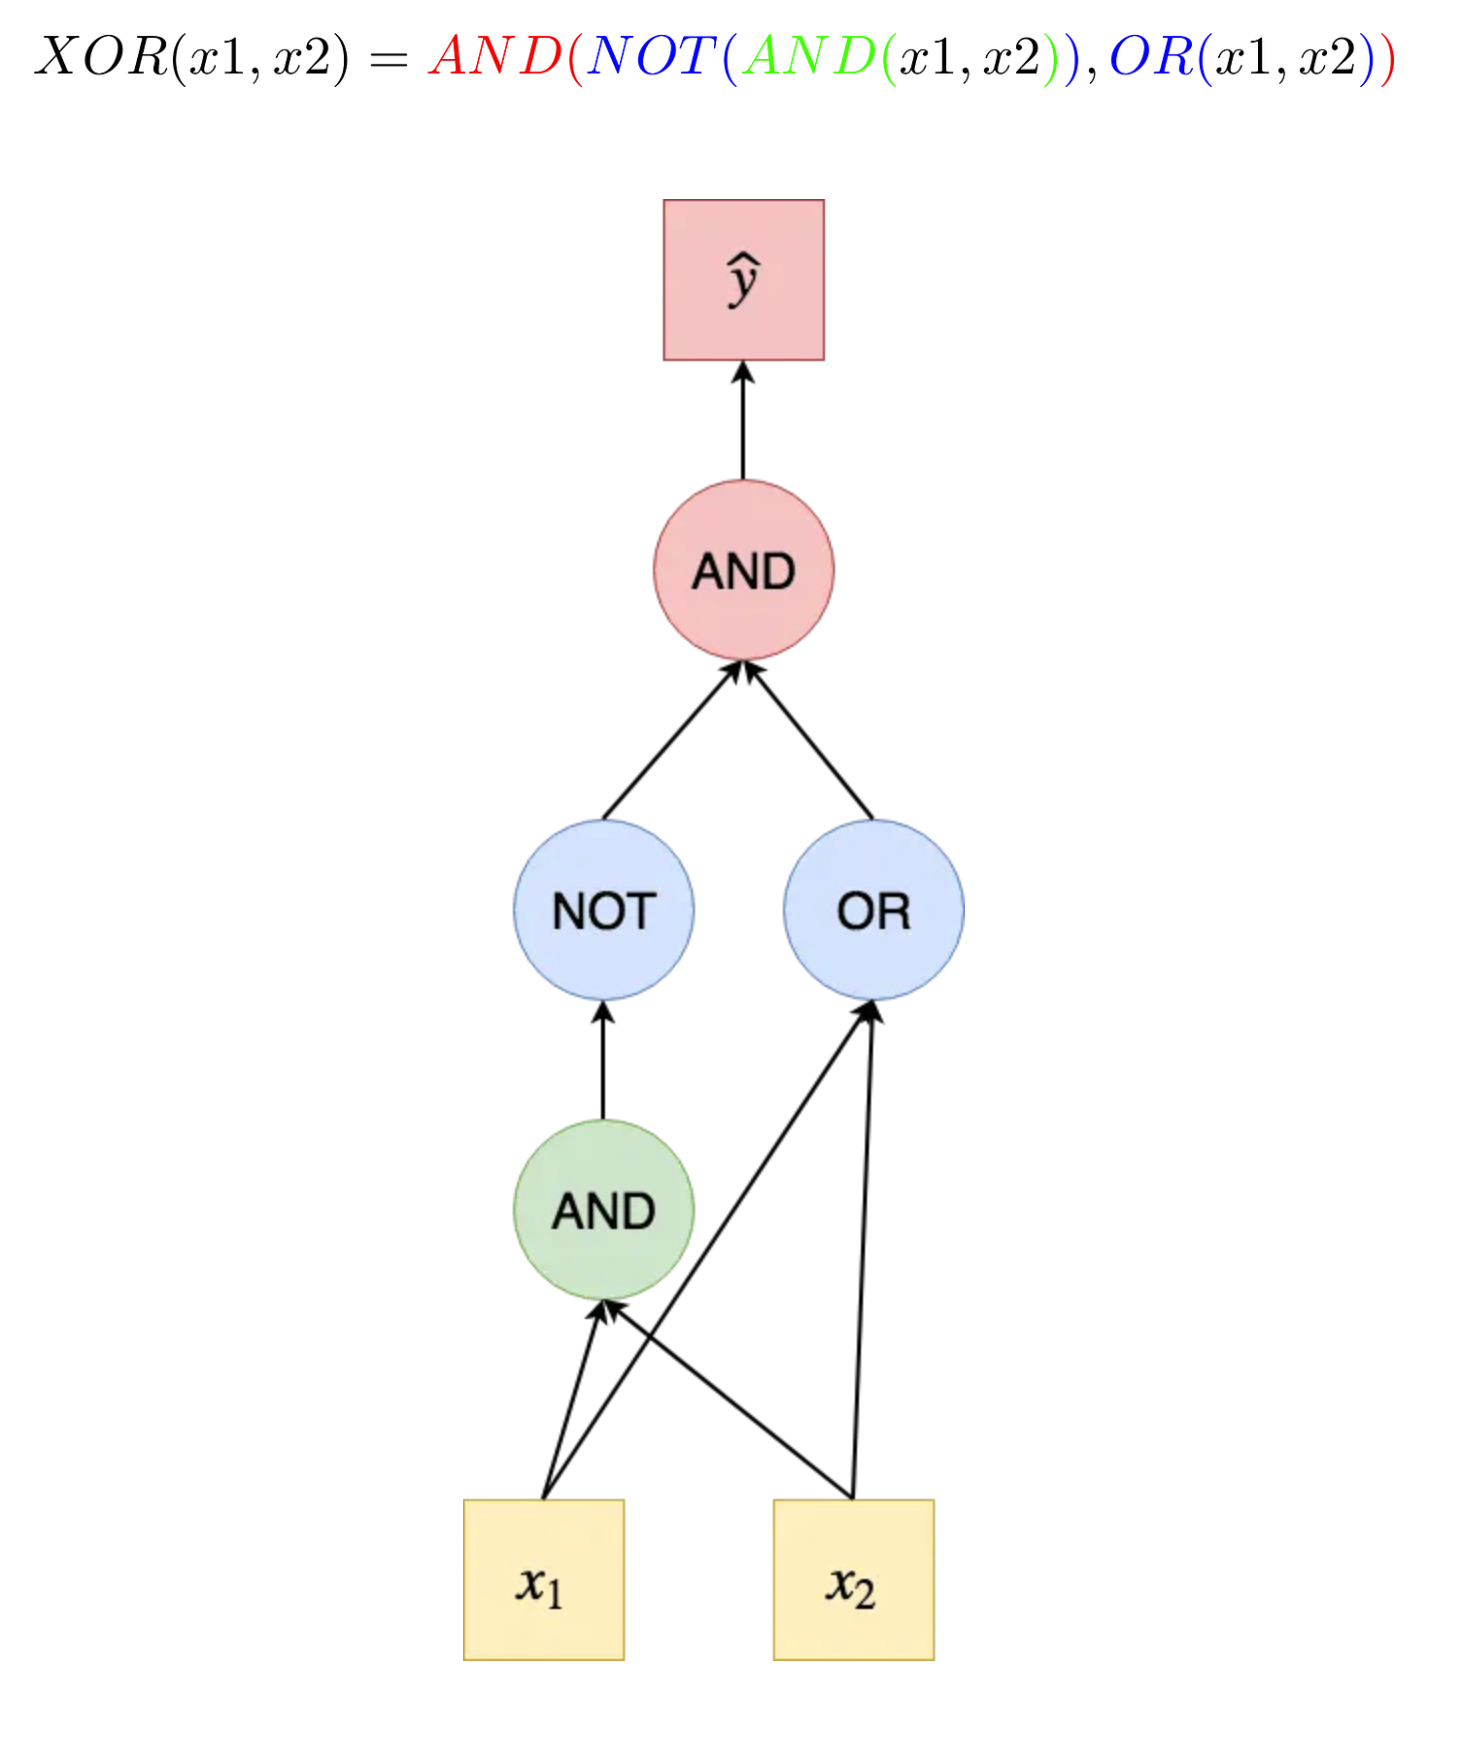

In [5]:
def XOR_net(x):
    gate_1 = AND_percep(x)
    gate_2 = NOT_percep(gate_1)
    gate_3 = OR_percep(x)
    new_x = np.array([gate_2, gate_3])
    output = AND_percep(new_x)
    return output

print("XOR({}, {}) = {}".format(1, 1, XOR_net(example1)))
print("XOR({}, {}) = {}".format(1, 0, XOR_net(example2)))
print("XOR({}, {}) = {}".format(0, 1, XOR_net(example3)))
print("XOR({}, {}) = {}".format(0, 0, XOR_net(example4)))

XOR(1, 1) = 0
XOR(1, 0) = 1
XOR(0, 1) = 1
XOR(0, 0) = 0
